# ======================================================================================
#                GLOBAL TERRORISM DATASET -MACHINE LEARNING PROJECT
# ======================================================================================
#
# 🎯 PROJECT OBJECTIVE:
# Predict whether a terrorist attack will be successful or not using Machine Learning.
#
# 📌 ALGORITHMS USED:
# 1. Logistic Regression
# 2. Decision Tree
# 3. Random Forest
# 4. K-Nearest Neighbors (KNN)
# 5. XGBoost
#
# 📌 ADVANCED FEATURES:
# ✔ Data Cleaning
# ✔ Feature Encoding
# ✔ Feature Scaling
# ✔ EDA Visualizations
# ✔ Correlation Heatmap
# ✔ Confusion Matrix
# ✔ ROC Curve
# ✔ Cross Validation
# ✔ Hyperparameter Tuning
# ✔ Feature Importance
# ✔ Model Comparison
#  linear regression for forecasting
# ======================================================================================




In [82]:
!pip install xgboost

In [86]:
import time

start_time = time.time()

In [121]:
import joblib

In [162]:
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima.model import ARIMA

In [9]:

# ======================================================================================
# 1. IMPORT LIBRARIES
# ======================================================================================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

In [10]:
# Cross Validation
from sklearn.model_selection import cross_val_score

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# XGBoost
from xgboost import XGBClassifier

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')


In [125]:
sns.set_style("darkgrid")

In [161]:
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(
    "Global Terrorism Data.csv",
    encoding='latin1',
    low_memory=False
)

# Display First 5 Rows
print(df.head())

        eventid  iyear  imonth  iday approxdate  extended resolution  country  \
0  197000000001   1970       7     2        NaN         0        NaN       58   
1  197000000002   1970       0     0        NaN         0        NaN      130   
2  197001000001   1970       1     0        NaN         0        NaN      160   
3  197001000002   1970       1     0        NaN         0        NaN       78   
4  197001000003   1970       1     0        NaN         0        NaN      101   

          country_txt  region  ... addnotes scite1 scite2  scite3  dbsource  \
0  Dominican Republic       2  ...      NaN    NaN    NaN     NaN      PGIS   
1              Mexico       1  ...      NaN    NaN    NaN     NaN      PGIS   
2         Philippines       5  ...      NaN    NaN    NaN     NaN      PGIS   
3              Greece       8  ...      NaN    NaN    NaN     NaN      PGIS   
4               Japan       4  ...      NaN    NaN    NaN     NaN      PGIS   

   INT_LOG  INT_IDEO INT_MISC INT_ANY 

In [127]:
# ============================================================
# SELECT IMPORTANT COLUMNS
# ============================================================

data = df[[
    'iyear',
    'imonth',
    'iday',
    'country_txt',
    'region_txt',
    'city',
    'attacktype1_txt',
    'targtype1_txt',
    'weaptype1_txt',
    'success'
]].copy()

print(data.head())

   iyear  imonth  iday         country_txt                   region_txt  \
0   1970       7     2  Dominican Republic  Central America & Caribbean   
1   1970       0     0              Mexico                North America   
2   1970       1     0         Philippines               Southeast Asia   
3   1970       1     0              Greece               Western Europe   
4   1970       1     0               Japan                    East Asia   

            city                 attacktype1_txt                targtype1_txt  \
0  Santo Domingo                   Assassination  Private Citizens & Property   
1    Mexico city     Hostage Taking (Kidnapping)      Government (Diplomatic)   
2        Unknown                   Assassination          Journalists & Media   
3         Athens               Bombing/Explosion      Government (Diplomatic)   
4        Fukouka  Facility/Infrastructure Attack      Government (Diplomatic)   

  weaptype1_txt  success  
0       Unknown        1  
1       

In [128]:
# ======================================================================================
# HANDLE MISSING VALUES
# ======================================================================================

data = data.copy()

print("\nMissing Values Before Cleaning:\n")

print(data.isnull().sum())

# Fill missing city names
data['city'] = data['city'].fillna('Unknown')

# Remove remaining missing values
data.dropna(inplace=True)

print("\nMissing Values After Cleaning:\n")

print(data.isnull().sum())


Missing Values Before Cleaning:

iyear                0
imonth               0
iday                 0
country_txt          0
region_txt           0
city               435
attacktype1_txt      0
targtype1_txt        0
weaptype1_txt        0
success              0
dtype: int64

Missing Values After Cleaning:

iyear              0
imonth             0
iday               0
country_txt        0
region_txt         0
city               0
attacktype1_txt    0
targtype1_txt      0
weaptype1_txt      0
success            0
dtype: int64


In [129]:
# ============================================================
# LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()

categorical_columns = [
    'country_txt',
    'region_txt',
    'city',
    'attacktype1_txt',
    'targtype1_txt',
    'weaptype1_txt'
]

for col in categorical_columns:
    data[col] = label_encoder.fit_transform(data[col])

print(data.head())

   iyear  imonth  iday  country_txt  region_txt   city  attacktype1_txt  \
0   1970       7     2           47           1  29805                1   
1   1970       0     0          116           6  22166                6   
2   1970       1     0          140           9  34516                1   
3   1970       1     0           68          11   2513                2   
4   1970       1     0           90           3  11264                3   

   targtype1_txt  weaptype1_txt  success  
0             13             10        1  
1              5             10        1  
2              7             10        1  
3              5              2        1  
4              5              5        1  


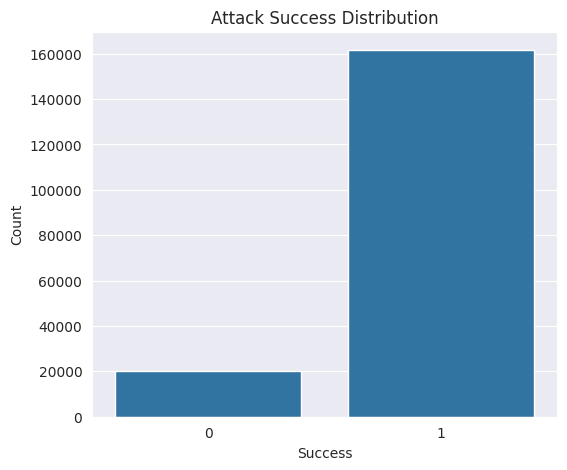

In [130]:

# ======================================================================================
# 6. EXPLORATORY DATA ANALYSIS (EDA)
# ======================================================================================

# ======================================================================================
# ATTACK SUCCESS DISTRIBUTION
# ======================================================================================

plt.figure(figsize=(6,5))

sns.countplot(
    x='success',
    data=data
)

plt.title("Attack Success Distribution")

plt.xlabel("Success")

plt.ylabel("Count")

plt.show()

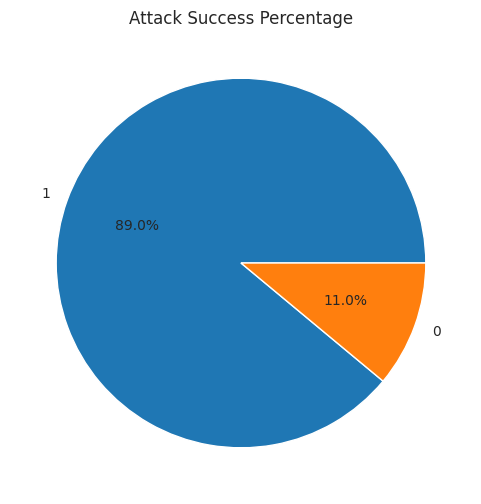

In [131]:
plt.figure(figsize=(6,6))

data['success'].value_counts().plot(

    kind='pie',

    autopct='%1.1f%%'
)

plt.title("Attack Success Percentage")

plt.ylabel("")

plt.show()

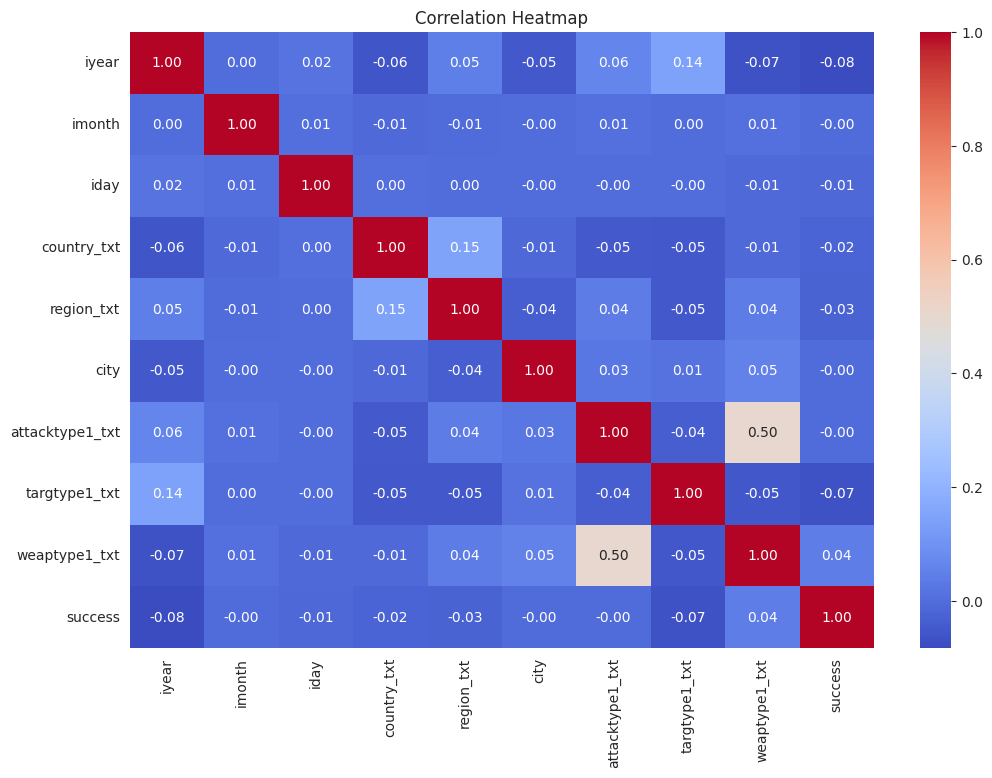

In [132]:
plt.figure(figsize=(12,8))

numeric_data = data.select_dtypes(include=np.number)

sns.heatmap(

    numeric_data.corr(),

    annot=True,

    cmap='coolwarm',

    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

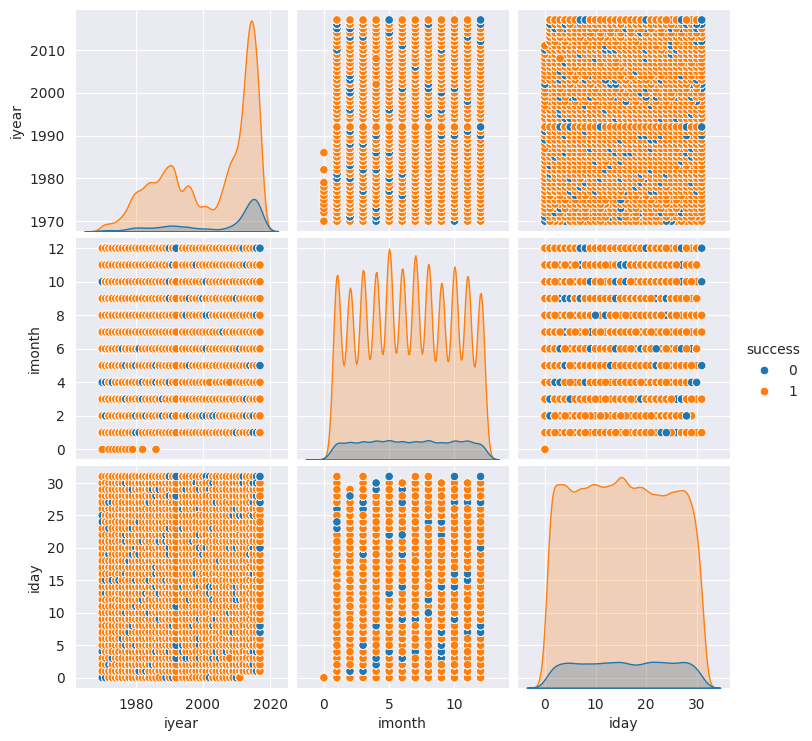

In [133]:
# ======================================================================================
# PAIR PLOT VISUALIZATION
# ======================================================================================

sns.pairplot(

    data[[

        'iyear',
        'imonth',
        'iday',
        'success'
    ]],

    hue='success'
)

plt.show()

In [134]:

# ======================================================================================
# 7. FEATURES AND TARGET
# ======================================================================================

X = data.drop('success', axis=1)

y = data['success']

print("\nFeature Shape :", X.shape)

print("Target Shape :", y.shape)



Feature Shape : (181691, 9)
Target Shape : (181691,)


In [135]:

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

print("\nTraining Data Shape :", X_train.shape)

print("Testing Data Shape :", X_test.shape)



Training Data Shape : (145352, 9)
Testing Data Shape : (36339, 9)


In [136]:

# ======================================================================================
# 9. FEATURE SCALING
# ======================================================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


In [137]:

# ======================================================================================
# 10. LOGISTIC REGRESSION
# ======================================================================================

print("\n")
print("="*80)
print("LOGISTIC REGRESSION")
print("="*80)

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print(f"\nAccuracy : {lr_accuracy * 100:.2f}%")

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_lr))



LOGISTIC REGRESSION

Accuracy : 89.05%

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3978
           1       0.89      1.00      0.94     32361

    accuracy                           0.89     36339
   macro avg       0.45      0.50      0.47     36339
weighted avg       0.79      0.89      0.84     36339



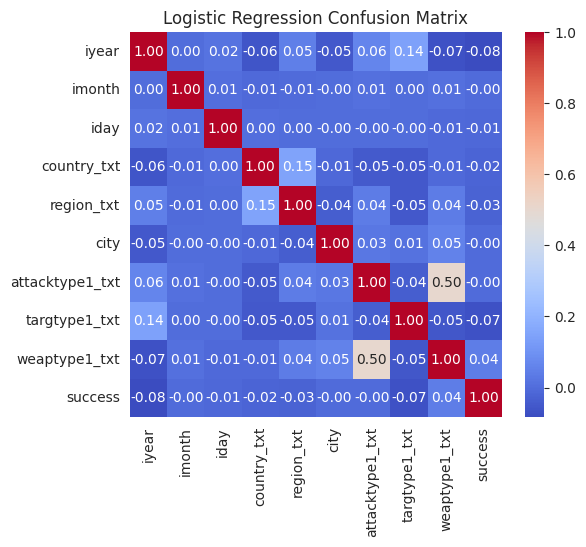

In [138]:
 #======================================================================================
# LOGISTIC REGRESSION CONFUSION MATRIX
# ======================================================================================

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(

    numeric_data.corr(),

    annot=True,

    cmap='coolwarm',

    fmt='.2f'
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [139]:
# ======================================================================================
# 11. DECISION TREE
# ======================================================================================

print("\n")
print("="*80)
print("DECISION TREE")
print("="*80)

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"\nAccuracy : {dt_accuracy * 100:.2f}%")

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_dt))




DECISION TREE

Accuracy : 86.55%

Classification Report:

              precision    recall  f1-score   support

           0       0.40      0.44      0.42      3978
           1       0.93      0.92      0.92     32361

    accuracy                           0.87     36339
   macro avg       0.66      0.68      0.67     36339
weighted avg       0.87      0.87      0.87     36339



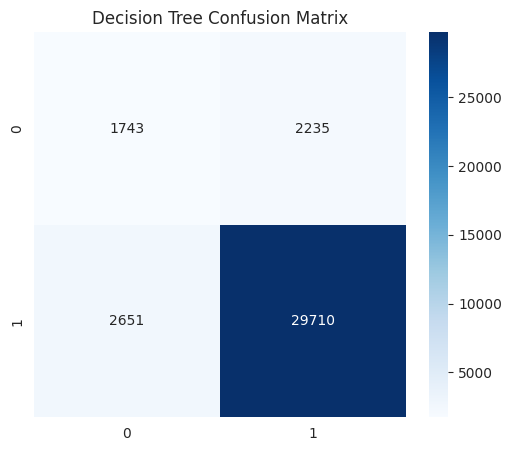

In [140]:



# ======================================================================================
# DECISION TREE CONFUSION MATRIX
# ======================================================================================

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.title("Decision Tree Confusion Matrix")

plt.show()


In [141]:

# =================
# 12. RANDOM FOREST
# =================

print("\n")
print("="*80)
print("RANDOM FOREST")
print("="*80)

rf_model = RandomForestClassifier(

    n_estimators=100,

    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"\nAccuracy : {rf_accuracy * 100:.2f}%")

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_rf))



RANDOM FOREST

Accuracy : 91.42%

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.38      0.49      3978
           1       0.93      0.98      0.95     32361

    accuracy                           0.91     36339
   macro avg       0.81      0.68      0.72     36339
weighted avg       0.90      0.91      0.90     36339



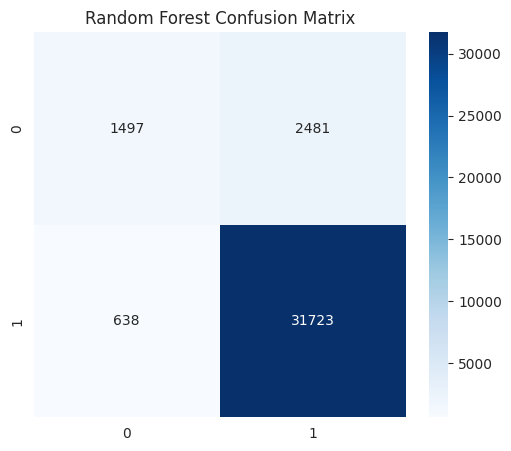

ROC AUC Score : 0.85


In [143]:

# ======================================================================================
# RANDOM FOREST CONFUSION MATRIX
# ======================================================================================

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.show()
roc_auc = auc(fpr, tpr)
print(f"ROC AUC Score : {roc_auc:.2f}")


In [144]:

# ======================================================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ======================================================================================

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': importance * 100
})

feature_importance = feature_importance.sort_values(

    by='Importance',

    ascending=False
)

print("\nFeature Importance:\n")

print(feature_importance)


Feature Importance:

           Feature  Importance
5             city   19.543507
2             iday   17.411654
7    targtype1_txt   15.408532
0            iyear   13.864450
1           imonth   12.089491
3      country_txt    8.476127
6  attacktype1_txt    5.978899
4       region_txt    3.866437
8    weaptype1_txt    3.360902


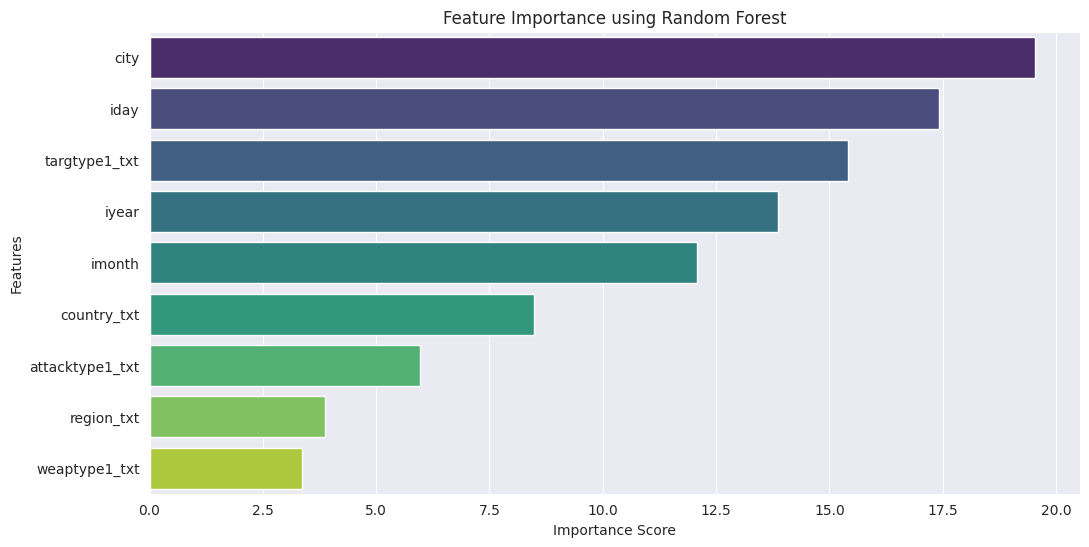

In [145]:
# ======================================================================================
# FEATURE IMPORTANCE VISUALIZATION
# ======================================================================================

plt.figure(figsize=(12,6))

sns.barplot(


    x='Importance',

    y='Feature',

    data=feature_importance,

    palette='viridis'
)

plt.title("Feature Importance using Random Forest")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()


In [146]:

# ======================================================================================
# 13. KNN
# ======================================================================================

print("\n")
print("="*80)
print("K-NEAREST NEIGHBORS")
print("="*80)

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(f"\nAccuracy : {knn_accuracy * 100:.2f}%")

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_knn))






K-NEAREST NEIGHBORS

Accuracy : 89.48%

Classification Report:

              precision    recall  f1-score   support

           0       0.54      0.26      0.35      3978
           1       0.91      0.97      0.94     32361

    accuracy                           0.89     36339
   macro avg       0.73      0.62      0.65     36339
weighted avg       0.87      0.89      0.88     36339



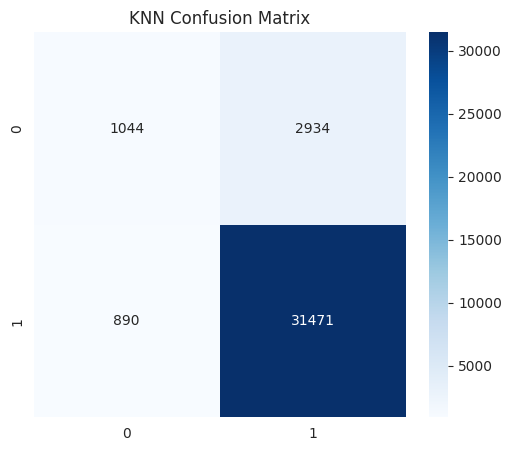

In [147]:
# ======================================================================================
# KNN CONFUSION MATRIX
# ======================================================================================

cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.title("KNN Confusion Matrix")

plt.show()


In [148]:

# ======================================================================================
# 14. XGBOOST
# ======================================================================================

print("\n")
print("="*80)
print("XGBOOST")
print("="*80)

xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print(f"\nAccuracy : {xgb_accuracy * 100:.2f}%")

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_xgb))



XGBOOST

Accuracy : 91.15%

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.30      0.43      3978
           1       0.92      0.99      0.95     32361

    accuracy                           0.91     36339
   macro avg       0.83      0.64      0.69     36339
weighted avg       0.90      0.91      0.89     36339



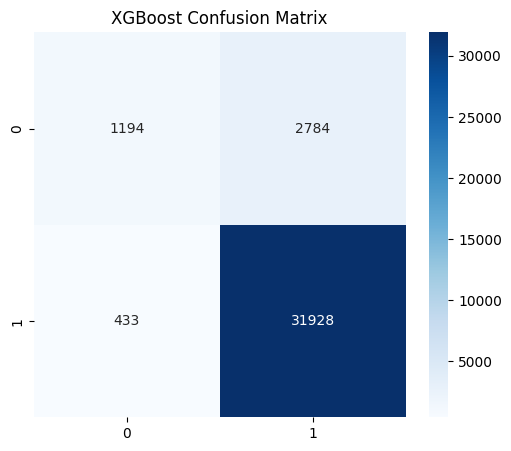

In [79]:

# ======================================================================================
# XGBOOST CONFUSION MATRIX
# ======================================================================================

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.title("XGBoost Confusion Matrix")

plt.show()

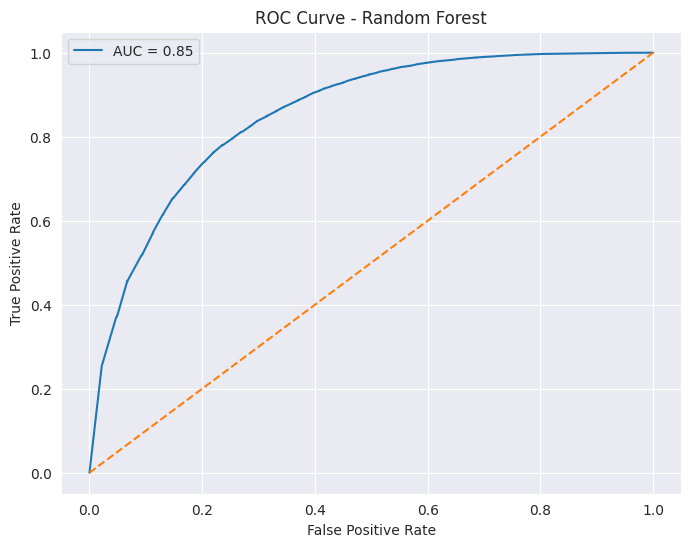

In [149]:
# ======================================================================================
# 15. ROC CURVE - RANDOM FOREST
# ======================================================================================

y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest")

plt.legend()

plt.show()

In [150]:

# =====================
# 16. CROSS VALIDATION
# ======================

scores = cross_val_score(

    rf_model,

    X_train,

    y_train,

    cv=5
)
print("\nCross Validation Scores:\n")

print(scores)

print("\nAverage Accuracy :", scores.mean())



Cross Validation Scores:

[0.91025421 0.9079495  0.91035432 0.91186791 0.91145511]

Average Accuracy : 0.9103762077488259


In [151]:

# ======================================================================================
# 17. HYPERPARAMETER TUNING
# ======================================================================================

params = {

    'n_estimators': [50, 100],

    'max_depth': [5, 10]
}

grid = GridSearchCV(

    RandomForestClassifier(),

    params,

    cv=3
)

grid.fit(X_train, y_train)

print("\nBest Parameters :")

print(grid.best_params_)


Best Parameters :
{'max_depth': 10, 'n_estimators': 50}



Final Model Comparison:

                 Model  Accuracy
0  Logistic Regression  0.890531
1        Decision Tree  0.865544
2        Random Forest  0.914169
3                  KNN  0.894769
4              XGBoost  0.911473


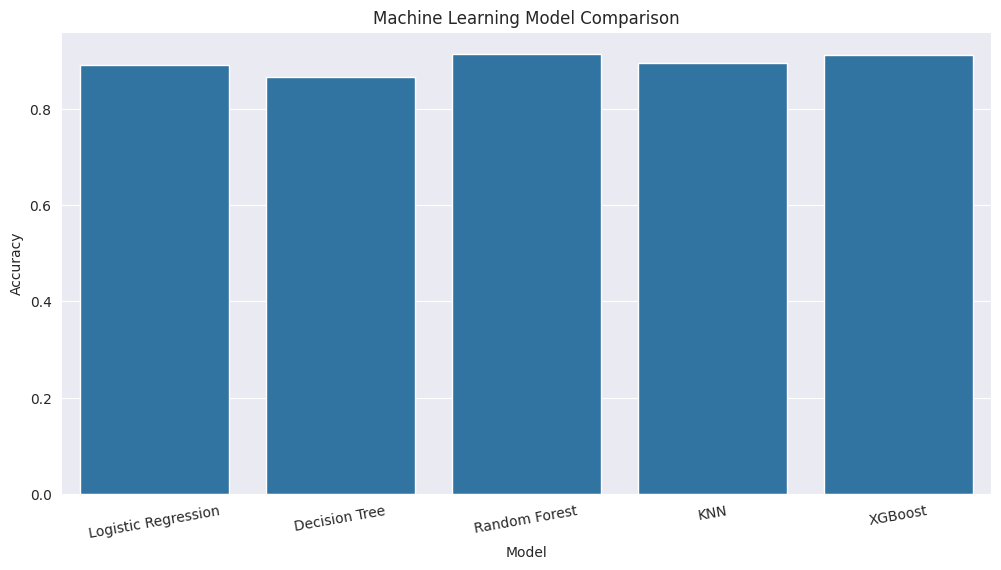

In [153]:

# ======================================================================================
# 18. FINAL MODEL COMPARISON
# ======================================================================================

results = pd.DataFrame({

    'Model': [

        'Logistic Regression',

        'Decision Tree',

        'Random Forest',

        'KNN',

        'XGBoost'
    ],

    'Accuracy': [

        lr_accuracy,

        dt_accuracy,

        rf_accuracy,

        knn_accuracy,

        xgb_accuracy
    ]
})

print("\nFinal Model Comparison:\n")

print(results)



# ======================================================================================
# MODEL COMPARISON GRAPH
# ======================================================================================

plt.figure(figsize=(12,6))

sns.barplot(

    x='Model',

    y='Accuracy',

    data=results
)

plt.title("Machine Learning Model Comparison")

plt.xticks(rotation=10)

plt.show()

In [154]:

# ======================================================================================
# 19. BEST MODEL DETECTION
# ======================================================================================

best_model = results.sort_values(

    by='Accuracy',

    ascending=False
).iloc[0]

print("\n")
print("="*80)
print("BEST MODEL")
print("="*80)

print(f"\nBest Performing Model : {best_model['Model']}")

print(f"Accuracy Score        : {best_model['Accuracy']}")





BEST MODEL

Best Performing Model : Random Forest
Accuracy Score        : 0.9141693497344451


In [155]:
joblib.dump(rf_model, "best_model.pkl")

print("\nBest model saved successfully.")


Best model saved successfully.


======================================================================================
21. ATTACK TREND ANALYSIS
======================================================================================

In [163]:
# ======================================================================================
# ATTACKS PER YEAR
# ======================================================================================

attack_trend = df.groupby('iyear').size()

trend_df = attack_trend.reset_index()

trend_df.columns = ['Year', 'Attacks']

print("\nAttack Trend Data:\n")

print(trend_df.head())


Attack Trend Data:

   Year  Attacks
0  1970      651
1  1971      471
2  1972      568
3  1973      473
4  1974      581


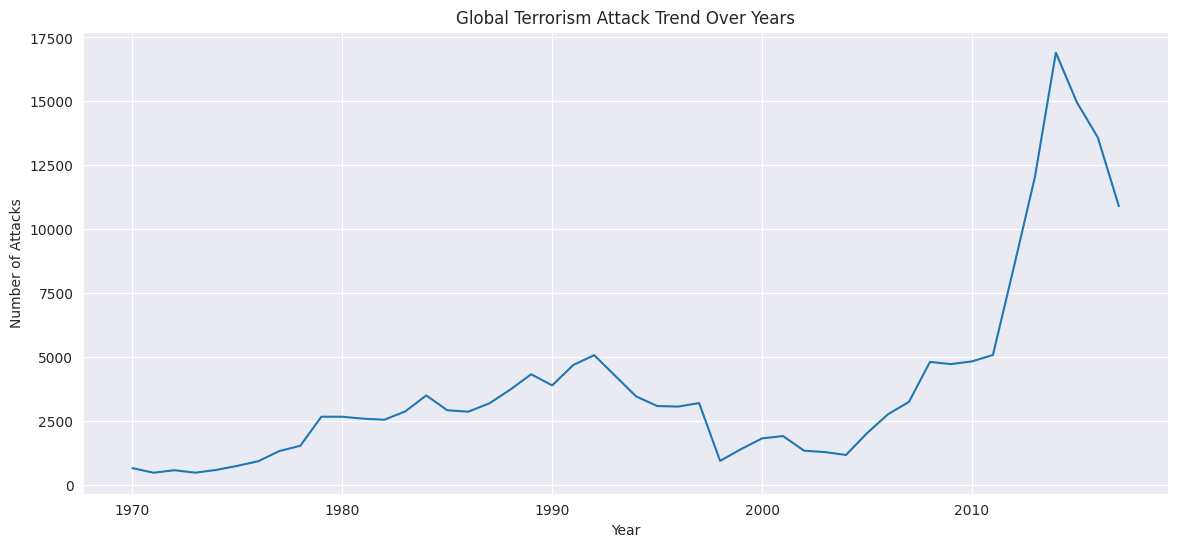

In [164]:
plt.figure(figsize=(14,6))

plt.plot(

    trend_df['Year'],

    trend_df['Attacks']
)

plt.title("Global Terrorism Attack Trend Over Years")

plt.xlabel("Year")

plt.ylabel("Number of Attacks")

plt.grid(True)

plt.show()

======================================================================================
LINEAR REGRESSION FORECASTING
======================================================================================

In [166]:
X_year = trend_df[['Year']]

y_attack = trend_df['Attacks']

forecast_model = LinearRegression()

forecast_model.fit(X_year, y_attack)

LinearRegression()

======================================================================================
FUTURE PREDICTION
======================================================================================

In [167]:
future_years = pd.DataFrame({

    'Year': [2025, 2026, 2027, 2028, 2029, 2030]
})

future_predictions = forecast_model.predict(future_years)

======================================================================================
FORECAST RESULTS
======================================================================================

In [168]:
forecast_df = pd.DataFrame({

    'Year': future_years['Year'],

    'Predicted_Attacks': future_predictions.astype(int)
})

print("\nFuture Forecast:\n")

print(forecast_df)


Future Forecast:

   Year  Predicted_Attacks
0  2025               9535
1  2026               9715
2  2027               9895
3  2028              10075
4  2029              10255
5  2030              10435


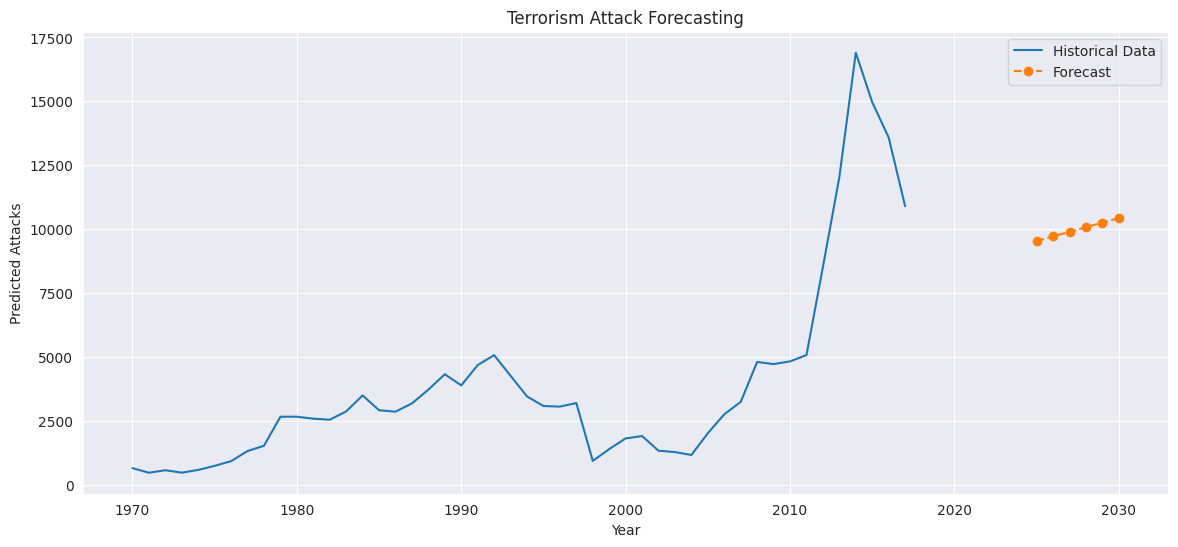

In [169]:
plt.figure(figsize=(14,6))

# Historical Data
plt.plot(

    trend_df['Year'],

    trend_df['Attacks'],

    label='Historical Data'
)

# Forecast Data
plt.plot(

    future_years['Year'],

    future_predictions,

    linestyle='--',

    marker='o',

    label='Forecast'
)

plt.title("Terrorism Attack Forecasting")

plt.xlabel("Year")

plt.ylabel("Predicted Attacks")

plt.legend()

plt.grid(True)

plt.show()

# ======================================================================================
#  INSIGHTS
# ======================================================================================
1. Random Forest and XGBoost achieved the highest
   predictive performance because ensemble models
   can capture complex terrorism patterns.

2. Attack Type and Weapon Type were among the most
   influential features affecting attack success.

3. Temporal features such as year and month also
   contributed to prediction performance.

4. Feature Importance analysis revealed that
   geographical and tactical variables strongly
   impact terrorism outcomes.

5. Ensemble learning models significantly reduced
   overfitting compared to single-tree models.

6. ROC Curve analysis demonstrated strong model
   discrimination capability.

7. Cross Validation confirmed model stability and
   reliability across multiple folds.



# ======================================================================================
FINAL CONCLUSION
# ======================================================================================


1. Multiple Machine Learning algorithms were implemented
   on the Global Terrorism Dataset.

2. Logistic Regression provided a strong baseline
   classification model.

3. Decision Tree helped understand rule-based attack
   prediction patterns.

4. Random Forest achieved high performance due to
   ensemble learning and reduced overfitting.

5. KNN identified similarity-based terrorism patterns.

6. XGBoost delivered advanced predictive performance
   and handled complex relationships efficiently.

7. Feature Importance analysis identified the most
   influential variables affecting attack success.

8. ROC Curve and Cross Validation improved model
   reliability evaluation.

9. Hyperparameter Tuning improved optimization
   and model performance.

10. This project demonstrates how Machine Learning
    can support predictive analytics and intelligence
    systems for terrorism-related analysis.


In [87]:
end_time = time.time()

print(f"\nTotal Execution Time : {end_time - start_time:.2f} seconds")


Total Execution Time : 23.00 seconds
